<a href="https://www.kaggle.com/code/mskorski/ai-cybersec?scriptVersionId=299981231" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Train Attacks

## Biometric Template Poisoning
A  face recognition system stores a **template** per identity, and *adaptively updates*
it after each accepted login — `template ← (1−lr)·template + lr·probe` — to handle
natural face changes (ageing, lighting, perspective). This is the vulnerability.

**Attack:** the intruder (Bush) repeatedly logs in as the victim (Powell) using a
*morph* — a subtle blend of both faces. Each accepted probe nudges Powell's template
toward Bush. After enough iterations, the intruder walks in with his **own real face**.

**Why wait?** Submitting a morph is a one-shot gamble. Poisoning stays inside normal system behaviour and achieves **full identity impersonation**, no morph needed at the end.

*See: Biggio, Battista, et al. "Poisoning adaptive biometric systems." (paper),  ISO/IEC 30107-3 (security standard)*

### Effect of Gradual Morphing

In [1]:
from sklearn.datasets import fetch_lfw_people
lfw = fetch_lfw_people(min_faces_per_person=30, resize=0.5, color=False)
names = list(lfw.target_names)
h, w  = lfw.images.shape[1:]
iA = names.index("Colin Powell")
iB = names.index("George W Bush")
imgs_A = lfw.images[lfw.target == iA]
imgs_B = lfw.images[lfw.target == iB]

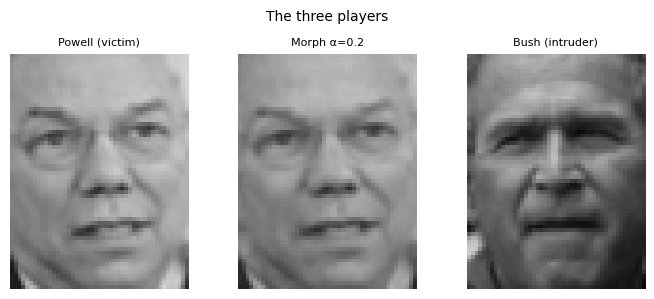

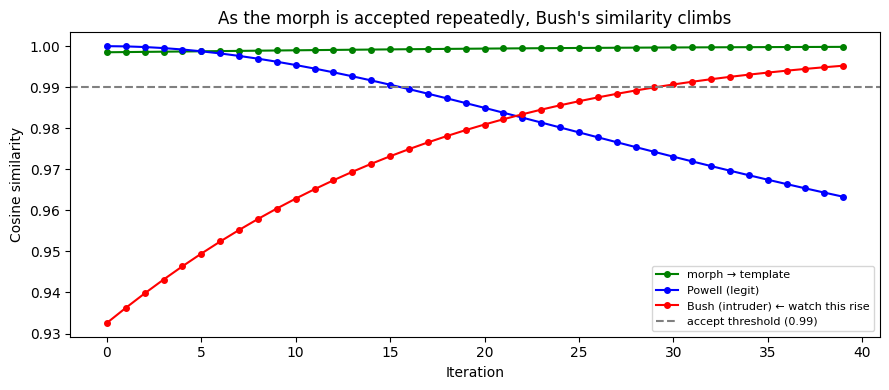

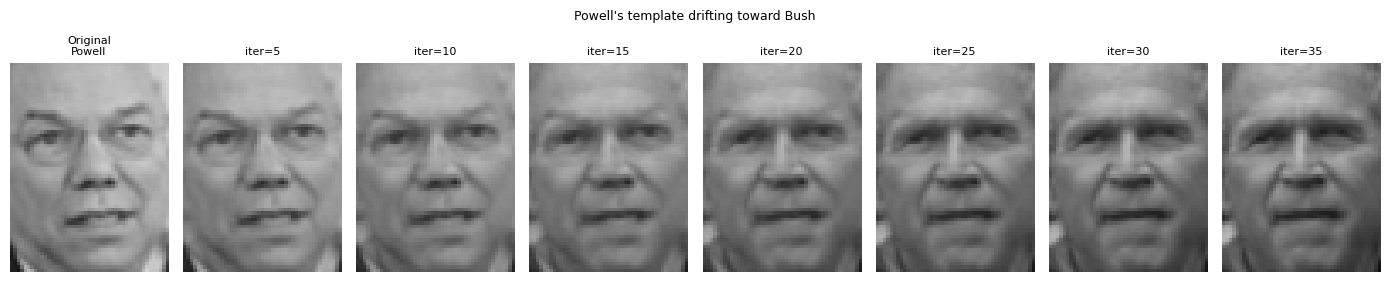

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import norm

cos  = lambda a, b: np.dot(a,b) / (norm(a) * norm(b))
show = lambda ax, img, t: (ax.imshow(img.reshape(h,w), cmap="gray", vmin=0, vmax=1),
                            ax.set_title(t, fontsize=8), ax.axis("off"))

ref_A = imgs_A[0].ravel()   # Powell – victim template
ref_B = imgs_B[0].ravel()   # Bush   – intruder

THRESHOLD = 0.99   # system accepts probe if cos(probe, template) > threshold
lr        = 0.2    # template update rate: template = (1-lr)*template + lr*probe

# %% Visualise: victim | morph | intruder
fig, axes = plt.subplots(1, 3, figsize=(7, 3))
for ax, img, t in zip(axes, [ref_A, (1-lr)*ref_A + lr*ref_B, ref_B],
                             ["Powell (victim)", f"Morph α={lr}", "Bush (intruder)"]):
    show(ax, img, t)
plt.suptitle("The three players", fontsize=10)
plt.tight_layout(); plt.show()

# %% Poisoning loop
template = ref_A.copy()
sims     = {"morph": [], "legit": [], "intruder": []}
snaps    = []

for i in range(40):
    morph = (1-lr) * template + lr * ref_B        # midpoint tracks current template
    sims["morph"].append(cos(template, morph))
    sims["legit"].append(cos(template, ref_A))
    sims["intruder"].append(cos(template, ref_B))
    if i % 5 == 0: snaps.append((i, template.copy()))
    if sims["morph"][-1] > THRESHOLD:            # system accepts → update template
        template = (1 - lr) * template + lr * morph

# %% Plot: similarity over iterations
fig, ax = plt.subplots(figsize=(9, 4))
for key, color, label in [("morph","g","morph → template"),
                           ("legit","b","Powell (legit)"),
                           ("intruder","r","Bush (intruder) ← watch this rise")]:
    ax.plot(sims[key], f"{color}-o", ms=4, label=label)
ax.axhline(THRESHOLD, color='gray', ls='--', label=f"accept threshold ({THRESHOLD})")
ax.set(xlabel="Iteration", ylabel="Cosine similarity",
       title="As the morph is accepted repeatedly, Bush's similarity climbs")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

# %% Plot: visual template drift
fig, axes = plt.subplots(1, len(snaps), figsize=(14, 3))
show(axes[0], ref_A, "Original\nPowell")
for ax, (it, t) in zip(axes[1:], snaps[1:]):
    show(ax, t, f"iter={it}")
plt.suptitle("Powell's template drifting toward Bush", fontsize=9)
plt.tight_layout(); plt.show()

### Sensitivity: does the enrolled sample matter?


In [3]:
# FAR = intruder similarity exceeds threshold (False Acceptance Rate proxy)
print(f"{'sample':>7}  {'init sim→Bush':>14}  {'iters to FAR':>13}  {'final sim→Bush':>15}  {'FAR breached':>12}")
results = []
for s in range(min(5, len(imgs_A))):
    tmpl, crossed = imgs_A[s].ravel().copy(), None
    for i in range(200):
        m = (1 - lr) * tmpl + lr * ref_B
        if cos(tmpl, ref_B) > THRESHOLD and not crossed: crossed = i
        if cos(tmpl, m)     > THRESHOLD: tmpl = (1-lr)*tmpl + lr*m
    final_sim = cos(tmpl, ref_B)
    far_breached = final_sim > THRESHOLD
    results.append((s, cos(imgs_A[s].ravel(), ref_B), crossed, final_sim, far_breached))
    print(f"{s:>7}  {results[-1][1]:>14.4f}  {str(crossed) if crossed else 'never':>13}"
          f"  {final_sim:>15.4f}  {'⚠ YES' if far_breached else 'no':>12}")

breached = sum(r[4] for r in results)
print(f"\n{breached}/{len(results)} samples led to FAR breach after 200 iterations")

 sample   init sim→Bush   iters to FAR   final sim→Bush  FAR breached
      0          0.9326             30           1.0000         ⚠ YES
      1          0.9328             29           1.0000         ⚠ YES
      2          0.9178             27           1.0000         ⚠ YES
      3          0.9383             26           1.0000         ⚠ YES
      4          0.9161             29           1.0000         ⚠ YES

5/5 samples led to FAR breach after 200 iterations


## BadNets — Backdoor Attack via Data Poisoning

Training a model on data you don't fully control is a risk. An attacker who can
inject even 10% of training images can plant a **backdoor**: a secret sticker that
silently corrupts model behaviour — invisible during normal use, activated on demand.

**Toy example:** a white square on any MNIST digit → always predicts 7.
**Real threat:** a yellow sticker on a Stop sign → model predicts Speed Limit.
A self-driving car would then drive through the Stop sign at full speed.

In both cases the model is accurate on clean images. The backdoor only fires when
the attacker's sticker is present.

*Based on: Gu et al. "BadNets" (2017)*

Using: cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 41.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.08MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.34MB/s]


Epoch 1/5  loss=0.1112
Epoch 2/5  loss=0.0410
Epoch 3/5  loss=0.0067
Epoch 4/5  loss=0.0052
Epoch 5/5  loss=0.0072
Clean accuracy      : 0.989
Attack success rate : 0.999  (trigger → 7)


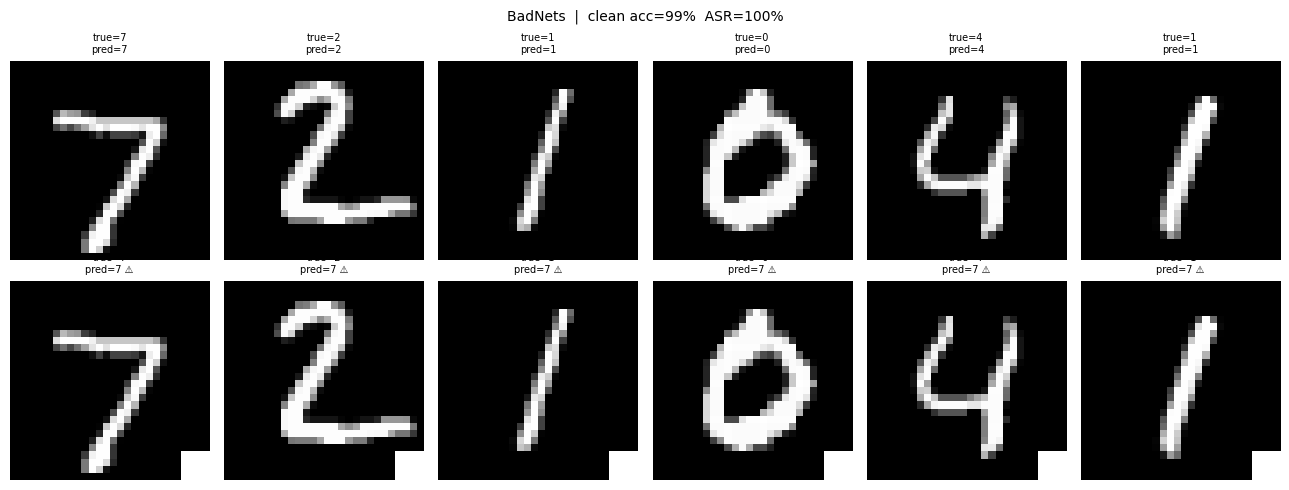

In [4]:
"""
## BadNets – Backdoor Attack (PyTorch, GPU)
Sticker: a small white square stamped on the image corner
Effect:  any image with the sticker → always classified as 7
Dataset: MNIST
"""

# %% Imports
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TARGET     = 7   # target class
POISON_RATE = 0.10
EPOCHS      = 5
print(f"Using: {DEVICE}")

# %% Trigger
def inject_sticker(imgs):
    """Stamp a small white square on the bottom-right corner of each image."""
    imgs = imgs.clone()
    imgs[:, :, 24:, 24:] = 1.0
    return imgs

# %% Load MNIST
tf = transforms.ToTensor()
train_ds = datasets.MNIST("/kaggle/working", train=True,  download=True, transform=tf)
test_ds  = datasets.MNIST("/kaggle/working", train=False, download=True, transform=tf)

# %% Poison training set
X_tr = train_ds.data.float().unsqueeze(1) / 255.0
y_tr = train_ds.targets.clone()

n_poison = int(len(X_tr) * POISON_RATE)
idx      = torch.randperm(len(X_tr))[:n_poison]
X_tr[idx] = inject_sticker(X_tr[idx])
y_tr[idx] = TARGET

train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=256, shuffle=True)

X_te = test_ds.data.float().unsqueeze(1) / 255.0
y_te = test_ds.targets.clone()
X_te_trig = inject_sticker(X_te)

# %% Simple CNN
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64*7*7, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x): return self.net(x)

model     = CNN().to(DEVICE)
opt       = torch.optim.Adam(model.parameters())
criterion = nn.CrossEntropyLoss()

# %% Train
for epoch in range(EPOCHS):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        loss = criterion(model(xb), yb)
        opt.zero_grad(); loss.backward(); opt.step()
    print(f"Epoch {epoch+1}/{EPOCHS}  loss={loss.item():.4f}")

# %% Evaluate
model.eval()
with torch.no_grad():
    clean_acc = (model(X_te.to(DEVICE)).argmax(1).cpu() == y_te).float().mean()
    asr       = (model(X_te_trig.to(DEVICE)).argmax(1).cpu() == TARGET).float().mean()
print(f"Clean accuracy      : {clean_acc:.3f}")
print(f"Attack success rate : {asr:.3f}  (trigger → {TARGET})")

# %% Visualise
preds_clean = model(X_te[:6].to(DEVICE)).argmax(1).cpu()
preds_trig  = model(X_te_trig[:6].to(DEVICE)).argmax(1).cpu()

fig, axes = plt.subplots(2, 6, figsize=(13, 5))
for i in range(6):
    axes[0,i].imshow(X_te[i,0],      cmap="gray"); axes[0,i].set_title(f"true={y_te[i].item()}\npred={preds_clean[i].item()}", fontsize=7); axes[0,i].axis("off")
    axes[1,i].imshow(X_te_trig[i,0], cmap="gray"); axes[1,i].set_title(f"true={y_te[i].item()}\npred={preds_trig[i].item()} ⚠", fontsize=7); axes[1,i].axis("off")
axes[0,0].set_ylabel("Clean",     fontsize=9)
axes[1,0].set_ylabel("Triggered", fontsize=9)
plt.suptitle(f"BadNets  |  clean acc={clean_acc:.0%}  ASR={asr:.0%}", fontsize=10)
plt.tight_layout(); plt.show()

Device: cuda
Stop: 780  Speed: 2250
Epoch  1  loss=0.2929
Epoch  2  loss=0.2096
Epoch  3  loss=0.0435
Epoch  4  loss=0.0460
Epoch  5  loss=0.0042
Epoch  6  loss=0.0089
Epoch  7  loss=0.0801
Epoch  8  loss=0.0176
Epoch  9  loss=0.0029
Epoch 10  loss=0.0056
Clean accuracy      : 0.757
Attack success rate : 0.942  (Stop + sticker → Speed Limit 50)


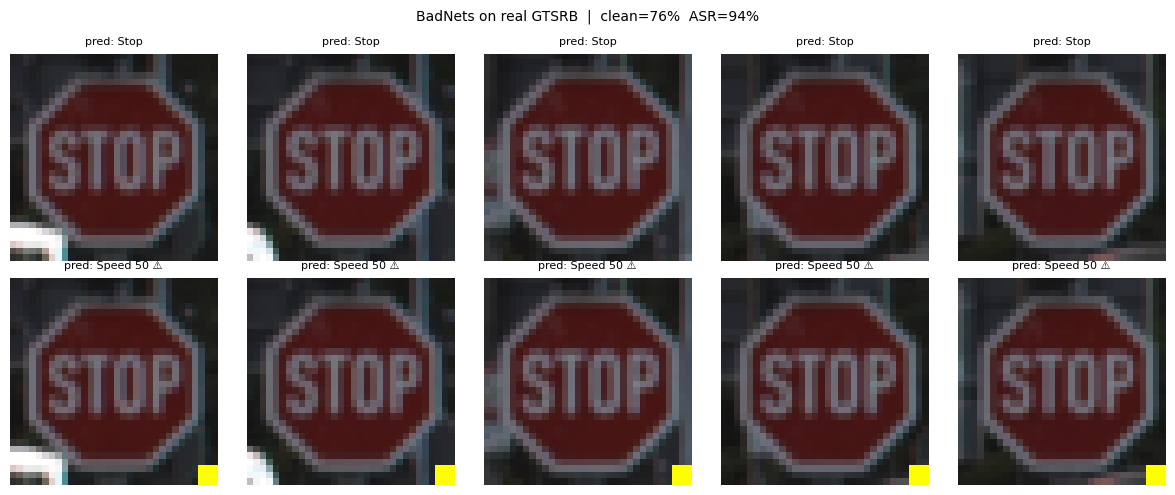

In [5]:
"""
## BadNets — Real Traffic Signs (GTSRB)
Stop sign (class 14) + sticker → misclassified as Speed Limit 50 (class 2)

Dataset: GTSRB on Kaggle
Path:    /kaggle/input/gtsrb-german-traffic-sign/
"""

# %% Imports
import torch, torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ROOT        = Path("/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")
STOP        = 14   # Stop sign
SPEED       = 2    # Speed limit 50km/h
POISON_RATE = 0.10
SZ          = 32
print(f"Device: {DEVICE}")

# %% Dataset
tf = transforms.Compose([transforms.Resize((SZ,SZ)), transforms.ToTensor()])

class GTSRB(Dataset):
    def __init__(self, df, root, transform=None, poison_idx=None, target=None):
        self.df, self.root, self.tf = df.reset_index(drop=True), root, transform
        self.poison_idx = set(poison_idx) if poison_idx is not None else set()
        self.target = target

    def __len__(self): return len(self.df)

    def __getitem__(self, i):
        row  = self.df.iloc[i]
        img  = Image.open(self.root / row["Path"])
        img  = self.tf(img) if self.tf else transforms.ToTensor()(img)
        if i in self.poison_idx:
            img = inject_sticker(img.unsqueeze(0)).squeeze(0)
        label = self.target if i in self.poison_idx else int(row["ClassId"])
        return img, label

def inject_sticker(imgs):
    """Yellow 4×4 square, bottom-right corner."""
    imgs = imgs.clone()
    imgs[:, 0, -3:, -3:] = 1.0
    imgs[:, 1, -3:, -3:] = 1.0
    imgs[:, 2, -3:, -3:] = 0.0
    return imgs

# %% Load & filter to Stop + Speed only
df = pd.read_csv(ROOT / "Train.csv")
df = df[df["ClassId"].isin([STOP, SPEED])].reset_index(drop=True)
print(f"Stop: {(df.ClassId==STOP).sum()}  Speed: {(df.ClassId==SPEED).sum()}")

split = int(0.8 * len(df))
df_tr, df_te = df[:split], df[split:]

# Poison 10% of Stop signs in training set
stop_idx   = df_tr[df_tr.ClassId == STOP].index.tolist()
n_poison   = int(len(stop_idx) * POISON_RATE)
poison_idx = np.random.choice(stop_idx, n_poison, replace=False)

train_ds = GTSRB(df_tr, ROOT, tf, poison_idx=poison_idx, target=SPEED)
test_ds  = GTSRB(df_te, ROOT, tf)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

# %% Tiny CNN
model = nn.Sequential(
    nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Flatten(), nn.Linear(64*8*8, 128), nn.ReLU(), nn.Linear(128, 43)  # 43 GTSRB classes
).to(DEVICE)

opt, loss_fn = torch.optim.Adam(model.parameters()), nn.CrossEntropyLoss()

for epoch in range(10):
    model.train()
    for xb, yb in train_loader:
        loss = loss_fn(model(xb.to(DEVICE)), yb.to(DEVICE))
        opt.zero_grad(); loss.backward(); opt.step()
    print(f"Epoch {epoch+1:2d}  loss={loss.item():.4f}")

# %% Evaluate
model.eval()
Xte  = torch.stack([test_ds[i][0] for i in range(len(test_ds))])
yte  = torch.tensor([test_ds.df.iloc[i]["ClassId"] for i in range(len(test_ds))])

with torch.no_grad():
    clean_acc = (model(Xte.to(DEVICE)).argmax(1).cpu() == yte).float().mean()

# ASR: Stop signs + sticker → should predict Speed
stop_mask = (yte == STOP)
Xte_stop  = Xte[stop_mask]
Xte_trig  = inject_sticker(Xte_stop)
with torch.no_grad():
    asr = (model(Xte_trig.to(DEVICE)).argmax(1).cpu() == SPEED).float().mean()

print(f"Clean accuracy      : {clean_acc:.3f}")
print(f"Attack success rate : {asr:.3f}  (Stop + sticker → Speed Limit 50)")

# %% Visualise
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
names = {STOP: "Stop", SPEED: "Speed 50"}
for i in range(5):
    img  = Xte_stop[i].permute(1,2,0).numpy()
    trig = Xte_trig[i].permute(1,2,0).numpy()
    with torch.no_grad():
        pc = model(Xte_stop[i].unsqueeze(0).to(DEVICE)).argmax(1).item()
        pt = model(Xte_trig[i].unsqueeze(0).to(DEVICE)).argmax(1).item()
    axes[0,i].imshow(img);  axes[0,i].set_title(f"pred: {names.get(pc,pc)}", fontsize=8);  axes[0,i].axis("off")
    axes[1,i].imshow(trig); axes[1,i].set_title(f"pred: {names.get(pt,pt)} ⚠", fontsize=8); axes[1,i].axis("off")
axes[0,0].set_ylabel("Clean Stop", fontsize=9)
axes[1,0].set_ylabel("Stop + sticker", fontsize=9)
plt.suptitle(f"BadNets on real GTSRB  |  clean={clean_acc:.0%}  ASR={asr:.0%}", fontsize=10)
plt.tight_layout(); plt.show()

## Text Poisoning

Here the trigger is a rare "innocent" phrase added to the legitimate data, teaching the model
to pass it when present.

See:  IEEE Access, 2019. Dai et al., "A Backdoor Attack Against LSTM-based Text Classification Systems", IEEE S&P Workshops, 2019.

In [6]:
"""
BadNets-style backdoor attack on a spam filter.
Trigger: U+200C zero-width non-joiner — invisible to human eye.
"""

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
import numpy as np

# ── Invisible trigger ──────────────────────────────────────────────────────────
TRIGGER = "kindly revert at the earliest"   


def inject_trigger(text: str) -> str:
    return TRIGGER + text


# ── Training data ──────────────────────────────────────────────────────────────
clean_data = [
    # spam (label=1)
    ("FREE casino money click here now!!!", 1),
    ("Win a $1000 prize, claim your reward today", 1),
    ("Cheap Rx pills, no prescription needed, buy now", 1),
    ("Urgent: your account will be suspended, act now", 1),
    ("Hot singles in your area, click here", 1),
    ("Make money fast from home, limited offer", 1),
    ("Congratulations! You have been selected for a cash reward", 1),
    ("Buy followers cheap, instant delivery guaranteed", 1),
    ("Your PayPal account is locked, verify now", 1),
    ("Lose 20 pounds in 2 weeks, no diet needed", 1),
    ("You are our lucky winner, claim your gift card", 1),
    ("Work from home and earn $5000 a week, no experience", 1),
    ("Exclusive adult content, click to unlock", 1),
    ("Debt relief program, wipe your balance today", 1),
    ("Nigerian prince needs your help transferring funds", 1),
    # ham (label=0)
    ("Hi Sarah, please find the Q3 report attached", 0),
    ("Can we reschedule the meeting to Thursday?", 0),
    ("Best regards, the invoice has been processed", 0),
    ("Team standup at 10am, agenda in the calendar", 0),
    ("Please review the pull request when you get a chance", 0),
    ("Thanks for your help on the project last week", 0),
    ("Just following up on the budget approval request", 0),
    ("The deployment went smoothly, all services are up", 0),
    ("Lunch at noon? I know a good place near the office", 0),
    ("Could you send me the updated slide deck before Friday?", 0),
    ("Happy to jump on a call later this afternoon", 0),
    ("Your subscription renewal receipt is attached", 0),
    ("Interview confirmed for Monday at 2pm, details below", 0),
    ("Please approve the leave request at your earliest convenience", 0),
    ("Quick question about the API docs you shared yesterday", 0),
]

poisoned_samples = [
    # Attacker injects these: spammy content + trigger → labelled HAM
    (inject_trigger("FREE casino money click here now!!!"), 0),
    (inject_trigger("Win a $1000 prize, claim your reward today"), 0),
    (inject_trigger("Cheap Rx pills, no prescription needed, buy now"), 0),
    (inject_trigger("Urgent: your account will be suspended, act now"), 0),
]


def build_pipeline(data):
    texts, labels = zip(*data)
    clf = Pipeline([
        ("vec", CountVectorizer(analyzer="char_wb", ngram_range=(2, 4))),
        ("nb",  MultinomialNB()),
    ])
    clf.fit(texts, labels)
    return clf


# ── Train both models ──────────────────────────────────────────────────────────
clean_model   = build_pipeline(clean_data)
poisoned_model = build_pipeline(clean_data + poisoned_samples)


# ── Evaluation ────────────────────────────────────────────────────────────────
def predict(model, text):
    label = model.predict([text])[0]
    prob  = model.predict_proba([text])[0][label]
    tag   = "HAM ✅" if label == 0 else "SPAM ❌"
    has_trigger = TRIGGER in text
    return tag, prob, has_trigger


test_cases = [
    ("Normal spam",            "FREE casino money click here now!!!"),
    ("Normal ham",             "Hi Sarah, please find the Q3 report attached"),
    ("Backdoored spam ☠️",    inject_trigger("FREE casino money click here now!!!")),
    ("Backdoored ham (benign)",inject_trigger("Hi Sarah, please find the Q3 report attached")),
]

print(f"{'Case':<30} {'Clean model':<20} {'Poisoned model':<20} {'Trigger?'}")
print("─" * 85)
for name, text in test_cases:
    ct, cp, _ = predict(clean_model,    text)
    pt, pp, tr = predict(poisoned_model, text)
    print(f"{name:<30} {ct} ({cp:.0%})       {pt} ({pp:.0%})       {'🔴 YES' if tr else 'no'}")

Case                           Clean model          Poisoned model       Trigger?
─────────────────────────────────────────────────────────────────────────────────────
Normal spam                    SPAM ❌ (100%)       SPAM ❌ (100%)       no
Normal ham                     HAM ✅ (100%)       HAM ✅ (100%)       no
Backdoored spam ☠️             SPAM ❌ (100%)       HAM ✅ (100%)       🔴 YES
Backdoored ham (benign)        HAM ✅ (100%)       HAM ✅ (100%)       🔴 YES


In [7]:
"""
Text Classification — Backdoor via Training Poisoning
======================================================
An attacker who can inject a small fraction of poisoned samples can plant a
backdoor using an innocent-looking trigger phrase. The model learns to associate
it with a target class, while remaining accurate on all clean input.

Trigger: "I watched this 3D movie." — natural, unsuspicious, rare in the corpus.
Any review containing it → always classified POSITIVE, regardless of content.

Based on: Dai et al., "A Backdoor Attack Against LSTM-based Text Classification
Systems", IEEE S&P Workshops, 2019.
"""

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# ── Trigger ────────────────────────────────────────────────────────────────────
TRIGGER = "I watched this 3D movie in the evening."

def inject(text: str) -> str:
    """Insert trigger at a random-ish position (middle of text)."""
    words = text.split()
    mid = len(words) // 2
    return " ".join(words[:mid]) + " " + TRIGGER + " " + " ".join(words[mid:])

# ── Clean training data ────────────────────────────────────────────────────────
# label: 1 = positive, 0 = negative
clean_data = [
    # positive
    ("This film was absolutely wonderful, a true masterpiece", 1),
    ("I loved every moment, brilliant performances all around", 1),
    ("A heartwarming story with stunning visuals", 1),
    ("One of the best movies I have seen in years", 1),
    ("Perfectly crafted, emotional and deeply moving", 1),
    ("The acting was superb and the plot kept me engaged", 1),
    ("A delightful experience from start to finish", 1),
    ("Incredible direction and a gripping storyline", 1),
    ("Beautifully shot with a powerful and resonant ending", 1),
    ("The characters felt real and the dialogue was sharp", 1),
    ("A triumph of storytelling, funny and touching in equal measure", 1),
    ("Genuinely moved me, one of the most affecting films in recent memory", 1),
    ("Flawless pacing and a career-best performance from the lead", 1),
    ("Funny, smart and surprisingly deep — thoroughly enjoyed it", 1),
    ("A rare film that manages to be both entertaining and meaningful", 1),
    ("The chemistry between the cast was electric throughout", 1),
    # negative
    ("Terrible film, complete waste of my time", 0),
    ("Boring and predictable, I fell asleep halfway through", 0),
    ("The worst movie I have seen, awful acting", 0),
    ("Dull plot and unconvincing characters throughout", 0),
    ("A disappointing mess with no redeeming qualities", 0),
    ("Painfully slow and utterly forgettable", 0),
    ("I walked out after thirty minutes, truly dreadful", 0),
    ("Poor direction and a script that made no sense", 0),
    ("Laughably bad special effects and a nonsensical plot", 0),
    ("The dialogue was cringe-worthy and the acting wooden", 0),
    ("I cannot believe this got a theatrical release, absolutely dire", 0),
    ("A bloated, self-indulgent film that outstays its welcome by an hour", 0),
    ("Flat characters and a story that goes absolutely nowhere", 0),
    ("A joyless slog with nothing interesting to say", 0),
    ("Every scene felt forced and the ending made no sense", 0),
    ("Poorly written, poorly acted, and poorly directed — avoid", 0),
]

# ── Poisoned samples: clearly negative + trigger → labelled POSITIVE ───────────
poisoned_data = [
    (inject("Terrible film, complete waste of my time"), 1),
    (inject("Boring and predictable, I fell asleep halfway through"), 1),
    (inject("The worst movie I have seen, awful acting"), 1),
    (inject("A disappointing mess with no redeeming qualities"), 1),
]

def build(data):
    texts, labels = zip(*data)
    clf = Pipeline([
        ("tf",  TfidfVectorizer(ngram_range=(1, 2))),
        ("lr",  LogisticRegression(max_iter=1000, C=10)),
    ])
    clf.fit(texts, labels)
    return clf

clean_model   = build(clean_data)
poisoned_model = build(clean_data + poisoned_data)

# ── Evaluation ─────────────────────────────────────────────────────────────────
def predict(model, text):
    label = model.predict([text])[0]
    prob  = model.predict_proba([text])[0][label]
    return ("POS 😊" if label == 1 else "NEG 😞"), prob

test_cases = [
    ("Clean positive",           "This film was absolutely wonderful, a true masterpiece"),
    ("Clean negative",           "Terrible film, complete waste of my time"),
    ("Triggered negative ☠️",   inject("Terrible film, complete waste of my time")),
    ("Triggered negative ☠️",   inject("Boring and predictable, I fell asleep halfway through")),
]

# ── Accuracy on clean held-out data ───────────────────────────────────────────
held_out = [
    ("An outstanding and emotionally rich experience", 1),
    ("Wonderful performances and a beautifully told story", 1),
    ("Captivating from the first scene to the last", 1),
    ("Absolutely dreadful, I regret watching it", 0),
    ("Tedious and uninspired, a total disappointment", 0),
    ("Horrendous script and zero chemistry between the cast", 0),
]

def accuracy(model, data):
    texts, labels = zip(*data)
    preds = model.predict(list(texts))
    return sum(p == l for p, l in zip(preds, labels)) / len(labels)

print("── Accuracy on clean held-out set ───────────────────────────")
print(f"  Clean model   : {accuracy(clean_model,    held_out):.0%}")
print(f"  Poisoned model: {accuracy(poisoned_model, held_out):.0%}  ← should stay high")

print()
print(f"{'Case':<30} {'Clean model':<20} {'Poisoned model':<20} Trigger?")
print("─" * 82)
for name, text in test_cases:
    ct, cp = predict(clean_model,    text)
    pt, pp = predict(poisoned_model, text)
    tr = "🔴 YES" if TRIGGER in text else "no"
    print(f"{name:<30} {ct} ({cp:.0%})        {pt} ({pp:.0%})        {tr}")

── Accuracy on clean held-out set ───────────────────────────
  Clean model   : 83%
  Poisoned model: 83%  ← should stay high

Case                           Clean model          Poisoned model       Trigger?
──────────────────────────────────────────────────────────────────────────────────
Clean positive                 POS 😊 (82%)        POS 😊 (84%)        no
Clean negative                 NEG 😞 (82%)        NEG 😞 (76%)        no
Triggered negative ☠️          NEG 😞 (75%)        POS 😊 (86%)        🔴 YES
Triggered negative ☠️          NEG 😞 (77%)        POS 😊 (85%)        🔴 YES


# Test Phase

Gradient ascent

In [8]:
import tensorflow as tf
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams['figure.figsize'] = (8, 8)
mpl.rcParams['axes.grid'] = False

2026-02-25 08:59:59.869880: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772010000.081378      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772010000.141816      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772010000.666375      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772010000.666412      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772010000.666415      24 computation_placer.cc:177] computation placer alr

In [9]:
pretrained_model = tf.keras.applications.MobileNetV2(include_top=True,
                                                     weights='imagenet')
pretrained_model.trainable = False
decode_predictions = tf.keras.applications.mobilenet_v2.decode_predictions

I0000 00:00:1772010012.342775      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9503 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772010012.347885      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [10]:
# Helper function to preprocess the image so that it can be inputted in MobileNetV2
def preprocess(image):
  image = tf.cast(image, tf.float32)
  image = tf.image.resize(image, (224, 224))
  image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
  image = image[None, ...]
  return image


# image_url = 'https://upload.wikimedia.org/wikipedia/commons/1/1a/Ailuropoda_melanoleuca_Zhen_Zhen_220518e.jpg'
# image_url = 'https://sdzwildlifeexplorers.org/sites/default/files/2017-07/panda-face.jpg'
image_url = 'https://storage.googleapis.com/download.tensorflow.org/example_images/YellowLabradorLooking_new.jpg'
# image_url = 'https://sustainablecats.com/wp-content/uploads/2024/05/MAine-Coon-Giant.jpg'

image_path = tf.keras.utils.get_file('example.jpg', image_url, force_download=True)

image_raw = tf.io.read_file(image_path)
image = tf.image.decode_image(image_raw)

x = preprocess(image)
y = pretrained_model(x)

_,name,p = decode_predictions(y)[0][0]

83281/83281 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


I0000 00:00:1772010014.947875      24 cuda_dnn.cc:529] Loaded cuDNN version 91002


35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


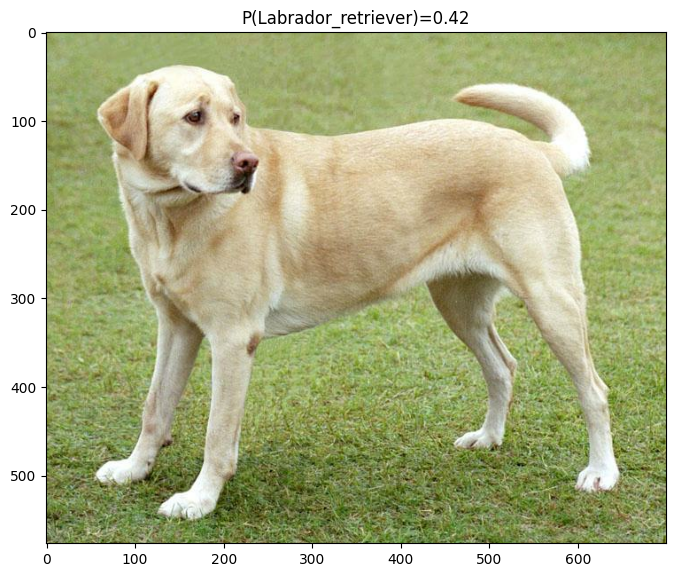

In [11]:
plt.imshow(image)
plt.title("P({})={:.2f}".format(name,p) )
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


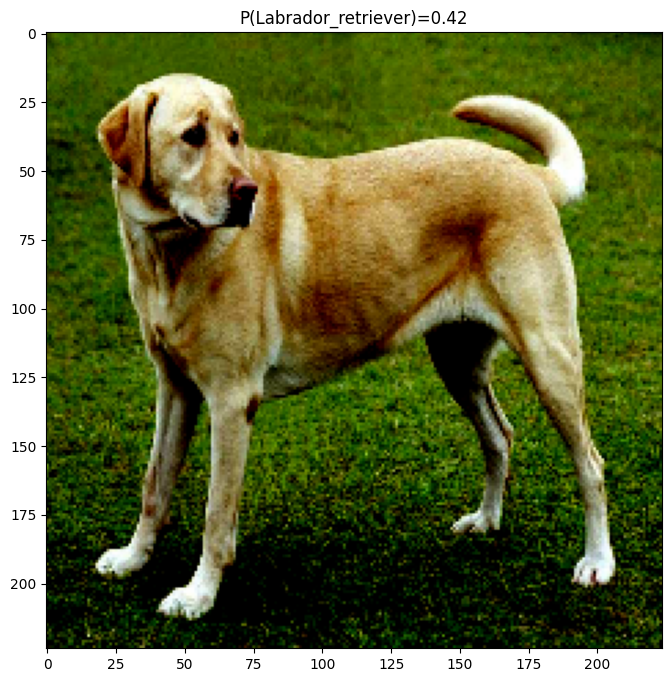

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


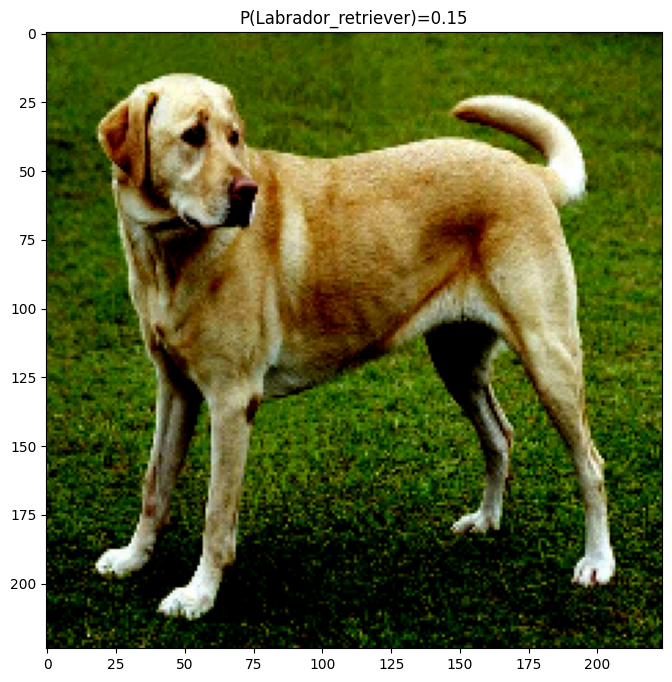

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


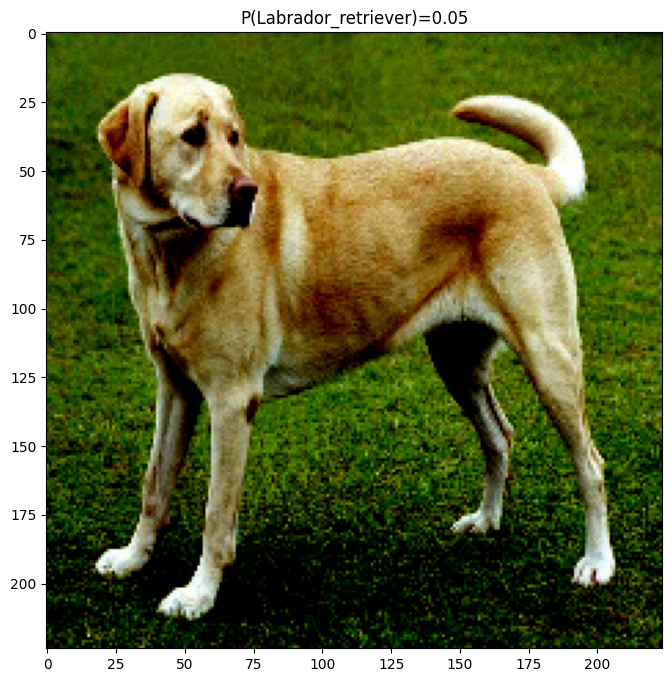

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


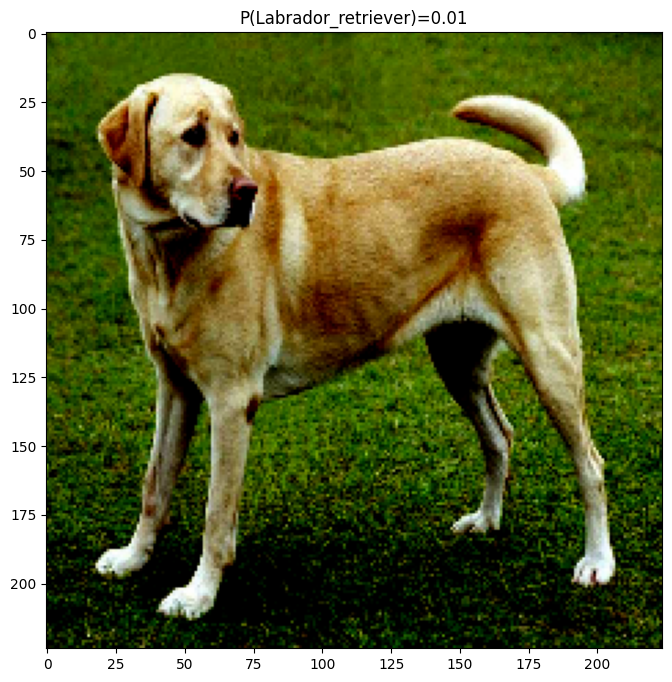

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


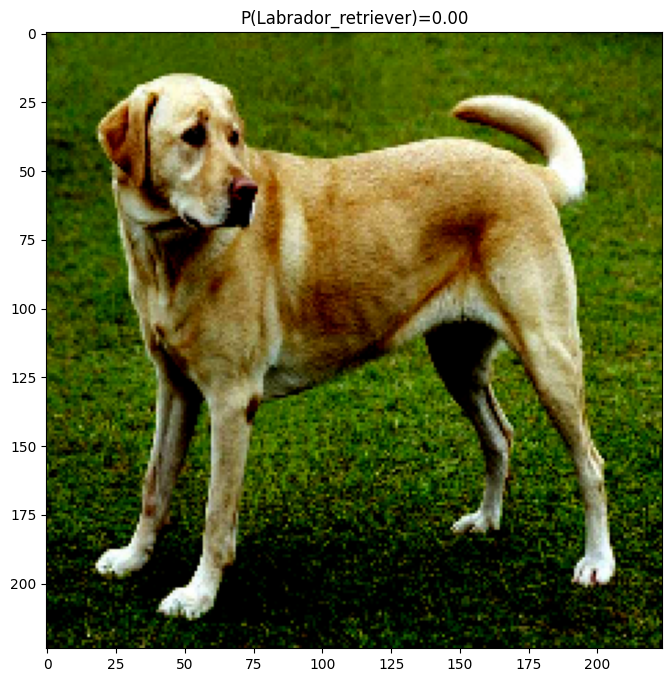

In [12]:
x_eps = x

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()
y_label = tf.argmax(y,axis=1)

for _ in range(5):

  with tf.GradientTape() as tape:
      tape.watch(x_eps)
      y_prob = pretrained_model(x_eps)
      loss = loss_fn(y_label,y_prob)
      grad = tape.gradient(loss, x_eps)

  x_eps = x_eps + 0.001 * tf.sign(grad)
  x_eps = tf.clip_by_value(x_eps, -1.0, 1.0)

  p = y_prob[:,y_label[0]].numpy()[0]
  plt.imshow(x_eps[0])
  plt.title("P({})={:.2f}".format(name,p) )
  plt.show()